# Supreme Court Judgments Dataset Analysis
### Exploratory Data Analysis & Extracted Legal Entity Insights

This notebook provides a comprehensive analysis of **38,235 Supreme Court of India judgments** and **2,889,841 extracted legal entities** from the Apache Parquet pipeline.

#### Data Files Topology (`data/supreme_court/parquet/`):
- **`metadata.parquet`**: 38,235 records (Document metadata: case titles, citations, bench, dates, page/word/char counts)
- **`entities.parquet`**: 2,889,841 records (Extracted entities: statutes, provisions, articles, precedents, judges, order rules)
- **`documents_text.parquet`**: 38,235 records (Full raw and clean text)

In [1]:
import os
import duckdb
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Data Paths
DATA_DIR = os.path.abspath('../data/supreme_court/parquet')
META_PATH = os.path.join(DATA_DIR, 'metadata.parquet')
ENTITIES_PATH = os.path.join(DATA_DIR, 'entities.parquet')
TEXT_PATH = os.path.join(DATA_DIR, 'documents_text.parquet')

print(f'Data Directory: {DATA_DIR}')
print(f'Metadata file exists: {os.path.exists(META_PATH)}')
print(f'Entities file exists: {os.path.exists(ENTITIES_PATH)}')
print(f'Text file exists: {os.path.exists(TEXT_PATH)}')

Data Directory: /home/duttadev/projects/aws_indian_judgements/data/supreme_court/parquet
Metadata file exists: True
Entities file exists: True
Text file exists: True


## 1. Zero-Copy Data Registration & Relational Verification (DuckDB)
Registering Parquet files as DuckDB views for instant, low-RAM querying over ~2.89 million records.

In [2]:
con = duckdb.connect(database=':memory:')

con.execute(f"CREATE VIEW metadata AS SELECT * FROM '{META_PATH}'")
con.execute(f"CREATE VIEW entities AS SELECT * FROM '{ENTITIES_PATH}'")

# Verify Record Counts
doc_count = con.execute("SELECT COUNT(*) FROM metadata").fetchone()[0]
ent_count = con.execute("SELECT COUNT(*) FROM entities").fetchone()[0]
unique_cases_with_entities = con.execute("SELECT COUNT(DISTINCT case_id) FROM entities").fetchone()[0]

print(f'Total Judgments Metadata Records: {doc_count:,}')
print(f'Total Extracted Entities Records: {ent_count:,}')
print(f'Judgments with Extracted Entities: {unique_cases_with_entities:,} ({unique_cases_with_entities/doc_count*100:.2f}%)')

Total Judgments Metadata Records: 38,235
Total Extracted Entities Records: 2,889,841
Judgments with Extracted Entities: 38,224 (99.97%)


## 2. Judgment Metadata Profiling & Temporal Trends
Analyzing document length (pages/words) and historical volume trends across Supreme Court judgments from 1950 to present.

In [3]:
# Key Metadata Summary Statistics
meta_stats = con.execute("""
SELECT 
    ROUND(AVG(page_count), 2) as avg_pages,
    MAX(page_count) as max_pages,
    ROUND(AVG(word_count), 2) as avg_words,
    MAX(word_count) as max_words,
    ROUND(AVG(char_count), 2) as avg_chars,
    MAX(char_count) as max_chars
FROM metadata
""").df()

meta_stats

,avg_pages,max_pages,avg_words,max_words,avg_chars,max_chars
0,15.93,1093,6033.47,485965,35126.31,2866781


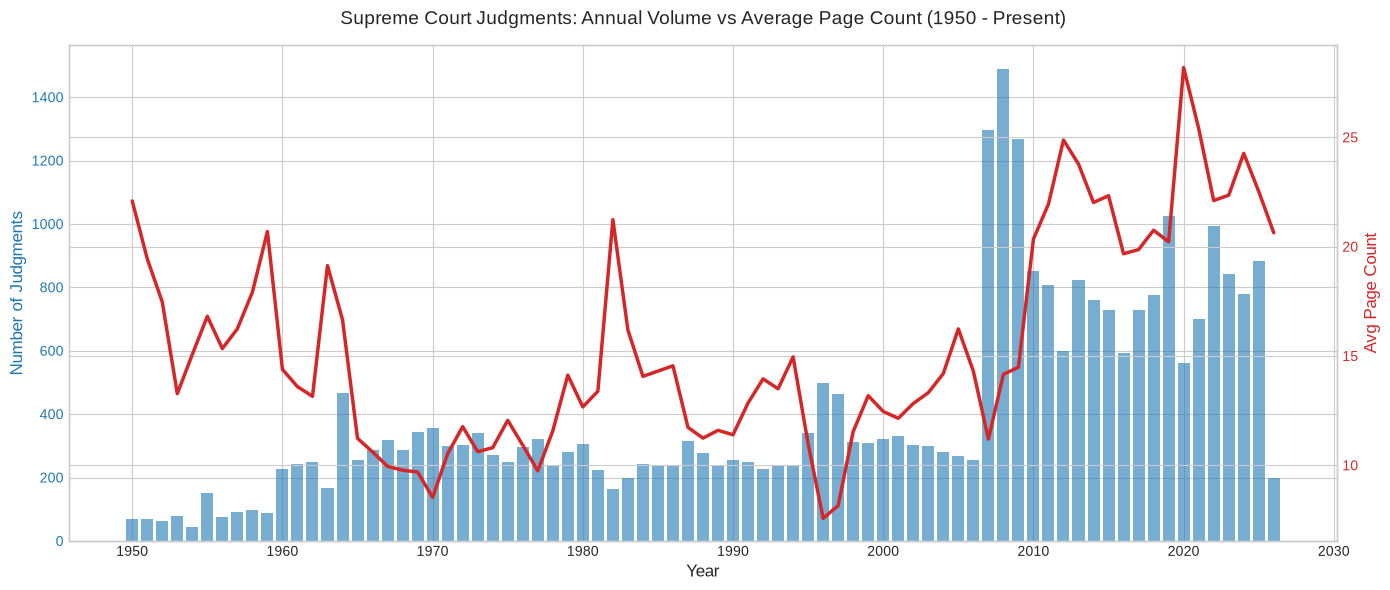

In [4]:
# Annual Volume vs Average Length Trend (Robust Year Extraction from date string or document_id)
year_df = con.execute(r"""
SELECT 
    COALESCE(
        TRY_CAST(REGEXP_EXTRACT(date, '\b(19\d{2}|20\d{2})\b', 1) AS INT),
        TRY_CAST(REGEXP_EXTRACT(document_id, '^(\d{4})', 1) AS INT)
    ) as year,
    COUNT(*) as judgment_count,
    AVG(page_count) as avg_pages,
    AVG(word_count) as avg_words
FROM metadata
WHERE COALESCE(
        TRY_CAST(REGEXP_EXTRACT(date, '\b(19\d{2}|20\d{2})\b', 1) AS INT),
        TRY_CAST(REGEXP_EXTRACT(document_id, '^(\d{4})', 1) AS INT)
    ) BETWEEN 1950 AND 2026
GROUP BY year
ORDER BY year
""").df()

fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Judgments', color=color, fontsize=12)
ax1.bar(year_df['year'], year_df['judgment_count'], color=color, alpha=0.6, label='Judgments Count')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Avg Page Count', color=color, fontsize=12)
ax2.plot(year_df['year'], year_df['avg_pages'], color=color, linewidth=2.5, label='Avg Pages per Judgment')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Supreme Court Judgments: Annual Volume vs Average Page Count (1950 - Present)', fontsize=14, pad=15)
fig.tight_layout()
plt.show()

## 3. Extracted Entity Taxonomy & Distribution
Breakdown of entity classes (`statute`, `section`, `article`, `order_rule`, `precedent`, `judge`, `court`, etc.) across all extracted records.

Entity Taxonomy Distribution:


,type,total_count,percentage,avg_confidence
0,section,1040970,36.02,0.90
1,statute,752628,26.04,0.95
2,date,585010,20.24,0.90
3,article,254464,8.81,0.95
4,monetary_value,169677,5.87,0.85
5,reporter_citation,33042,1.14,0.95
6,order_rule,17257,0.60,0.90
7,coram,17072,0.59,0.90
8,annexure,15759,0.55,0.90
9,neutral_citation,3961,0.14,1.00


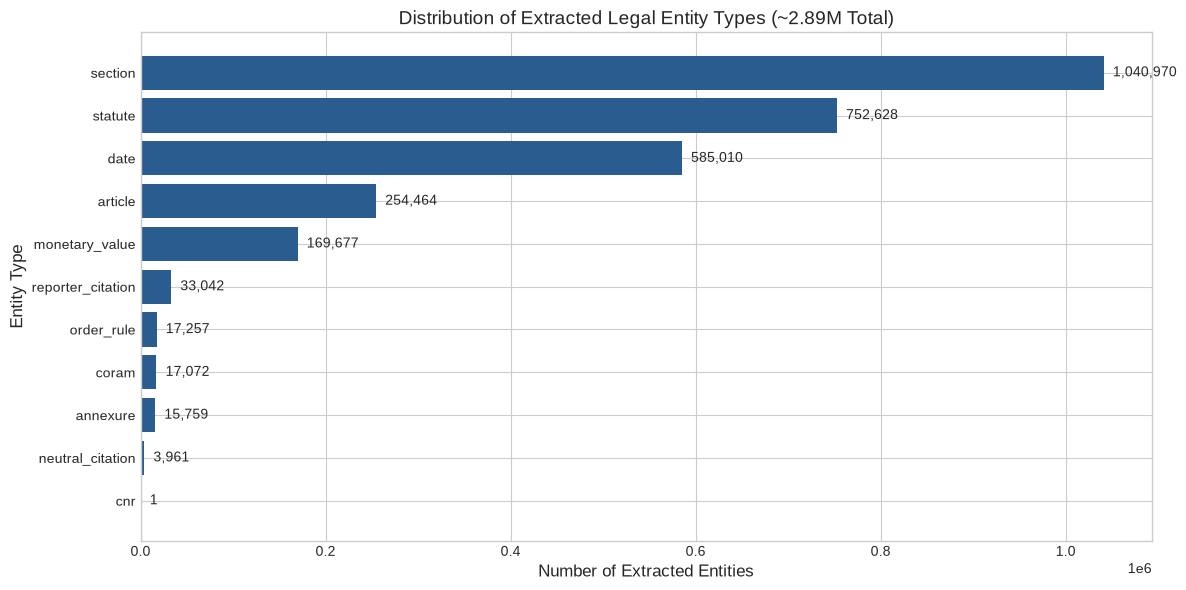

In [5]:
# Entity Type Frequency & Confidence
entity_types_df = con.execute("""
SELECT 
    type,
    COUNT(*) as total_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM entities), 2) as percentage,
    ROUND(AVG(confidence), 4) as avg_confidence
FROM entities
GROUP BY type
ORDER BY total_count DESC
""").df()

print('Entity Taxonomy Distribution:')
display(entity_types_df)

# Plot Entity Type Frequencies
plt.figure(figsize=(12, 6))
bars = plt.barh(entity_types_df['type'], entity_types_df['total_count'], color='#2b5c8f')
plt.xlabel('Number of Extracted Entities', fontsize=12)
plt.ylabel('Entity Type', fontsize=12)
plt.title('Distribution of Extracted Legal Entity Types (~2.89M Total)', fontsize=14)
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10000, bar.get_y() + bar.get_height()/2, f'{width:,}', 
             va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_266285/3929208955.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_statutes, y='statute_name', x='citation_count', palette='Blues_r')


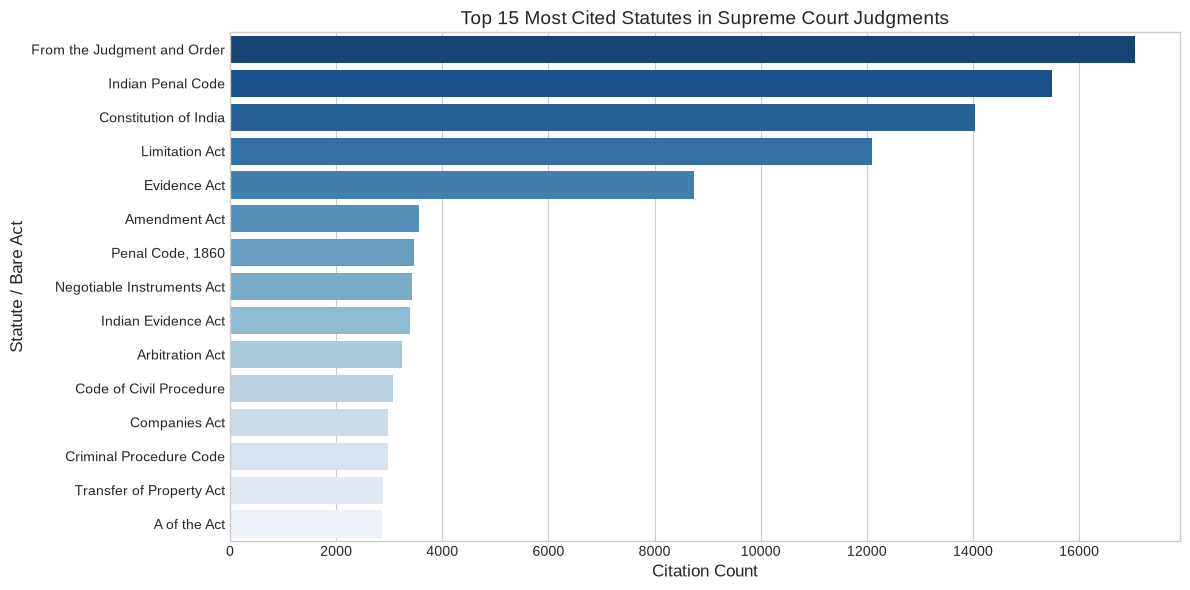

In [6]:
# Top 15 Most Cited Statutes
top_statutes = con.execute("""
SELECT 
    canonical as statute_name,
    COUNT(*) as citation_count
FROM entities
WHERE type = 'statute' AND canonical IS NOT NULL AND canonical != ''
GROUP BY canonical
ORDER BY citation_count DESC
LIMIT 15
""").df()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_statutes, y='statute_name', x='citation_count', palette='Blues_r')
plt.title('Top 15 Most Cited Statutes in Supreme Court Judgments', fontsize=14)
plt.xlabel('Citation Count', fontsize=12)
plt.ylabel('Statute / Bare Act', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Relational Cross-Analysis (`metadata` $\times$ `entities`)
Joining `metadata.document_id` with `entities.case_id` to evaluate entity density per document across judicial eras.

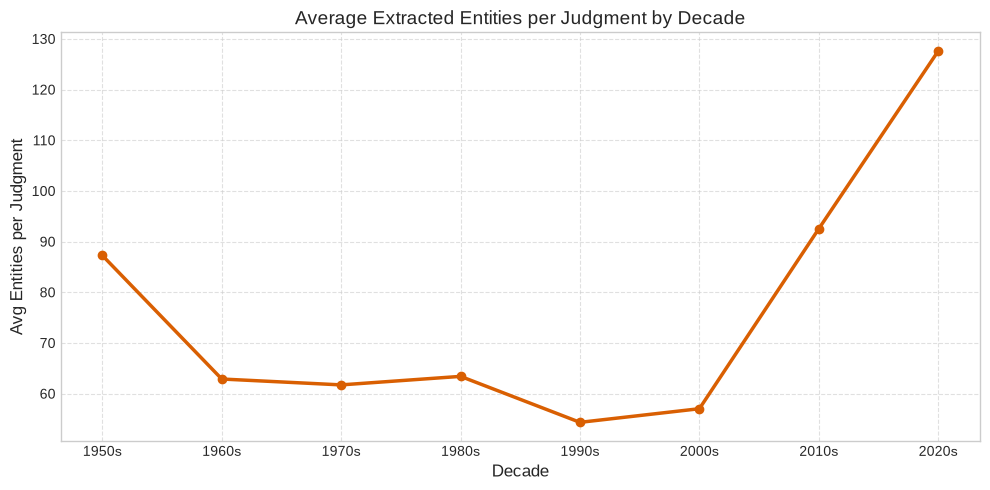

In [7]:
# Average Entities Extracted Per Judgment by Decade
decade_density = con.execute(r"""
WITH doc_years AS (
    SELECT 
        document_id,
        COALESCE(
            TRY_CAST(REGEXP_EXTRACT(date, '\b(19\d{2}|20\d{2})\b', 1) AS INT),
            TRY_CAST(REGEXP_EXTRACT(document_id, '^(\d{4})', 1) AS INT)
        ) as year
    FROM metadata
),
entity_counts AS (
    SELECT case_id, COUNT(*) as ent_count 
    FROM entities 
    GROUP BY case_id
)
SELECT 
    TRY_CAST(FLOOR(dy.year / 10) * 10 AS INT) as decade,
    COUNT(DISTINCT dy.document_id) as total_docs,
    ROUND(AVG(ec.ent_count), 2) as avg_entities_per_doc
FROM doc_years dy
JOIN entity_counts ec ON dy.document_id = ec.case_id
WHERE dy.year BETWEEN 1950 AND 2026
GROUP BY decade
ORDER BY decade
""").df()

plt.figure(figsize=(10, 5))
plt.plot(decade_density['decade'].astype(str) + 's', decade_density['avg_entities_per_doc'], 
         marker='o', linewidth=2.5, color='#d95f02')
plt.title('Average Extracted Entities per Judgment by Decade', fontsize=14)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Avg Entities per Judgment', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Pipeline Quality & Completeness Audit
Evaluating null rates, citation completeness, and entity extraction confidence scores.

In [8]:
# Metadata Completeness
meta_nulls = con.execute("""
SELECT 
    COUNT(*) as total_documents,
    COUNT(citation) as documents_with_citation,
    COUNT(date) as documents_with_date,
    COUNT(petitioner) as documents_with_petitioner,
    COUNT(respondent) as documents_with_respondent,
    ROUND((1.0 - COUNT(citation)*1.0/COUNT(*)) * 100, 2) as null_citation_pct
FROM metadata
""").df()

print('Metadata Quality & Completeness Audit:')
display(meta_nulls)

# Entity Confidence Summary
conf_summary = con.execute("""
SELECT 
    type,
    ROUND(MIN(confidence), 4) as min_confidence,
    ROUND(AVG(confidence), 4) as avg_confidence,
    ROUND(MAX(confidence), 4) as max_confidence,
    COUNT(CASE WHEN confidence < 0.8 THEN 1 END) as low_confidence_count
FROM entities
GROUP BY type
ORDER BY avg_confidence ASC
""").df()

print('Entity Extraction Confidence Scores Audit:')
display(conf_summary)

Metadata Quality & Completeness Audit:


,total_documents,documents_with_citation,documents_with_date,documents_with_petitioner,documents_with_respondent,null_citation_pct
0,38235,2284,2424,1135,1135,94.03


Entity Extraction Confidence Scores Audit:


,type,min_confidence,avg_confidence,max_confidence,low_confidence_count
0,monetary_value,0.85,0.85,0.85,0
1,coram,0.90,0.90,0.90,0
2,annexure,0.90,0.90,0.90,0
3,order_rule,0.90,0.90,0.90,0
4,date,0.90,0.90,0.90,0
5,section,0.90,0.90,0.90,0
6,article,0.95,0.95,0.95,0
7,statute,0.95,0.95,0.95,0
8,reporter_citation,0.95,0.95,0.95,0
9,cnr,1.00,1.00,1.00,0
